In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs # make_blobs is used to produce dataset for clusters

In [2]:
X,y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4, # how many true cluster do we want
    random_state=42
)
# X is actual dataa and y is there clusters ese to unlabel data hota hai but make_blob me data generate hota hai usme pahle se hi y diya hota hai jisme wo batata ki ki konse cluster ka part hai halanki yeha ham y ka use nhi karne wale beacuse unlabeld data hi hota hai real life me jisme ham clusters find out karte hai 

<Axes: >

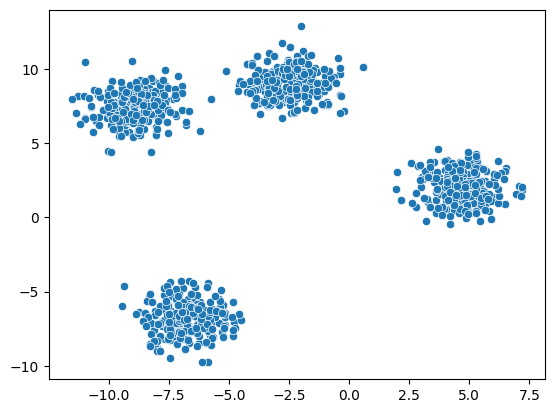

In [3]:
# Visualize
sns.scatterplot(x=X[:,0],y=X[:,1])

In [4]:
# it is very very important to scale data before clustering
# here it is already scaled but in real life data always do scalling befor applying any clustering algorithm

In [5]:
# K-Means Clustering
from sklearn.cluster import KMeans

In [6]:
''' 
in unsupervised ml we dont have any known y value 
jaha per ham testing kar paye so we dont do train test split 
in unsupervised kyuki supervised me ham train test split karte 
the waha per pahle se hi y ki value pata hoti thi to ham testing 
kar pate the but yeha esaa kuch nhi hai ham testing kar hi nhi 
sakte kyuki data labelled nhi hai isliye ham unsupervised
me train test split nhi karte hai
in unsupervised ham chahte hai ki poore ke poore data se pattern
identify ho


'''

' \nin unsupervised ml we dont have any known y value \njaha per ham testing kar paye so we dont do train test split \nin unsupervised kyuki supervised me ham train test split karte \nthe waha per pahle se hi y ki value pata hoti thi to ham testing \nkar pate the but yeha esaa kuch nhi hai ham testing kar hi nhi \nsakte kyuki data labelled nhi hai isliye ham unsupervised\nme train test split nhi karte hai\nin unsupervised ham chahte hai ki poore ke poore data se pattern\nidentify ho\n\n\n'

In [7]:
K = 4

kmeans = KMeans(
    n_clusters=K,
    random_state=42
)

In [8]:
labels = kmeans.fit_predict(X)  # in unsupervised ham har ek data poitns ke liye kuch individually kuch predict nhi karte balki sare data points ke liye kuch patterns ko identify karte hai to isliye ham fit_predict ek sath karte hai unlike upervised supervised me ham pahle training data me train karte the then predict but yeha per ha, poore dataa ke liye patterns identify kar rhe to alag sepredict nho ho rha na hi alaag se train jaisa kuch ho rha yeha per given data me patterns identify ho rhe using data points to fit prdict sath me ho rha isliye fit_predict
# yeha per lables aayenge jaha labels matlab cluster number

<Axes: >

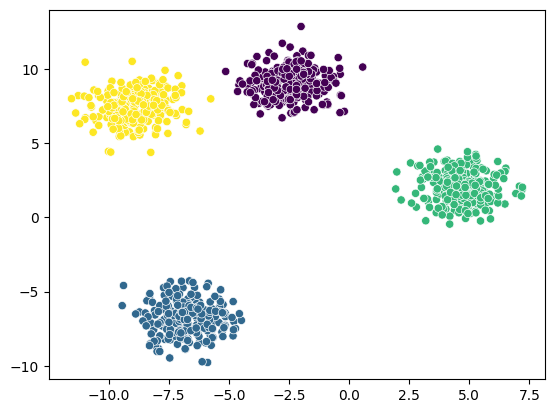

In [9]:
sns.scatterplot(x=X[:,0],y=X[:,1],c=labels)

### Choose our K value - elbow,sihouette score

In [10]:
#1 elbow method 



wcss = []
for k in range(1,21):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)



<Axes: >

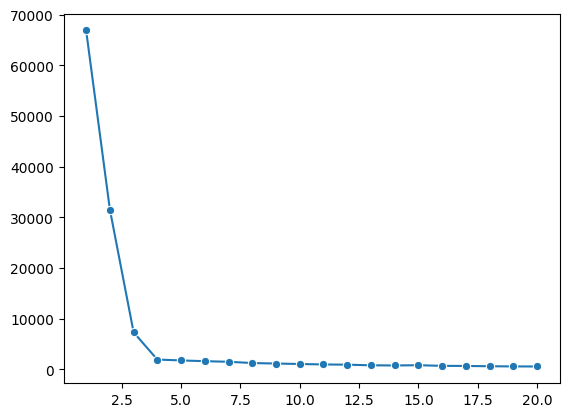

In [11]:
# manual method
sns.lineplot(x = range(1,21),y=wcss,marker = 'o')

In [12]:
#  by using kneed module

from kneed import KneeLocator

knee = KneeLocator(range(1,21),wcss,curve="convex",direction="decreasing")
print("optinal k value : ",knee.elbow)


optinal k value :  4


In [ ]:
#2 Silhouette Score
from sklearn.metrics import silhouette_score

ss = []

for k in range (2,21):  # whenever we calculate silhuote score number of cluster couldnt be 1 and 1 ka koi logic bhi nhi hai
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X,labels)
    ss.append(score)

<Axes: >

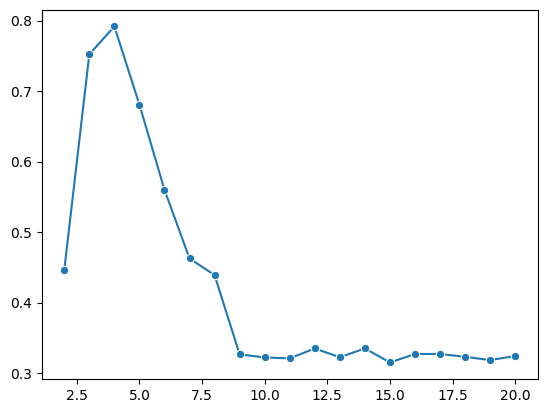

In [15]:
# plot k & ss

sns.lineplot(x=range(2,21),y=ss,marker='o')